In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df=pd.read_excel(r"C:\Users\hp\Desktop\google_review1.xlsx")

In [4]:
df.head()

,Unnamed: 0,User,Church,resort,beaches,parks,theatres,museums,malls,zoo,...,art_gallerie,dance_clubs,swimming_pools,gyms,bakeries,beauty_spas,cafes,viewpoints,monuments,gardens
0,0,User 1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,1,User 2,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
2,2,User 3,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
3,3,User 4,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0
4,4,User 5,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,...,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0


In [5]:
df.shape

(5456, 26)

In [6]:
df.info()    # local service is in object change its data type into float 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              5456 non-null   int64  
 1   User                    5456 non-null   object 
 2   Church                  5456 non-null   float64
 3   resort                  5456 non-null   float64
 4   beaches                 5456 non-null   float64
 5   parks                   5456 non-null   float64
 6   theatres                5456 non-null   float64
 7   museums                 5456 non-null   float64
 8   malls                   5456 non-null   float64
 9   zoo                     5456 non-null   float64
 10  restaurant              5456 non-null   float64
 11  pubs_bar                5456 non-null   float64
 12  local_service           5456 non-null   object 
 13  burger_pizza shop       5455 non-null   float64
 14   hotels_other_lodgings  5456 non-null   

In [7]:
df.isnull().sum()   # 1 missing value in burger_pizza_shop and gardens 

Unnamed: 0                0
User                      0
Church                    0
resort                    0
beaches                   0
parks                     0
theatres                  0
museums                   0
malls                     0
zoo                       0
restaurant                0
pubs_bar                  0
local_service             0
burger_pizza shop         1
 hotels_other_lodgings    0
juice_bars                0
art_gallerie              0
dance_clubs               0
swimming_pools            0
gyms                      0
bakeries                  0
beauty_spas               0
cafes                     0
viewpoints                0
monuments                 0
gardens                   1
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['local_service'] = pd.to_numeric(df['local_service'], errors='coerce')   # changing the datatype into float

In [10]:
# dropping missing value 
df=df.dropna()

In [11]:
df.shape

(5454, 26)

In [24]:
df = df.drop(columns=['Unnamed: 0', 'User'], errors='ignore')
df.shape

(5454, 24)

In [25]:
std = StandardScaler()
df1 = pd.DataFrame(std.fit_transform(df), columns=df.columns)

In [27]:
df1.var()

Church                    1.000183
resort                    1.000183
beaches                   1.000183
parks                     1.000183
theatres                  1.000183
museums                   1.000183
malls                     1.000183
zoo                       1.000183
restaurant                1.000183
pubs_bar                  1.000183
local_service             1.000183
burger_pizza shop         1.000183
 hotels_other_lodgings    1.000183
juice_bars                1.000183
art_gallerie              1.000183
dance_clubs               1.000183
swimming_pools            1.000183
gyms                      1.000183
bakeries                  1.000183
beauty_spas               1.000183
cafes                     1.000183
viewpoints                1.000183
monuments                 1.000183
gardens                   1.000183
dtype: float64

In [30]:
df1.mean()

Church                   -3.647817e-17
resort                   -1.042234e-17
beaches                  -6.513960e-17
parks                    -1.654546e-16
theatres                  3.152757e-16
museums                   2.397137e-16
malls                    -3.387259e-17
zoo                      -3.126701e-17
restaurant                5.002721e-16
pubs_bar                 -1.511239e-16
local_service             4.690051e-17
burger_pizza shop         1.511239e-16
 hotels_other_lodgings   -2.970366e-16
juice_bars                7.816752e-17
art_gallerie             -2.188690e-16
dance_clubs               4.950609e-17
swimming_pools            5.211168e-18
gyms                      1.745741e-16
bakeries                  8.077310e-17
beauty_spas              -1.563350e-17
cafes                    -1.250680e-16
viewpoints               -9.119544e-17
monuments                -9.119544e-17
gardens                   2.032355e-16
dtype: float64

In [31]:
pca=PCA()
pca_fit=pca.fit(df1)
pca_df=pca_fit.transform(df1)

In [32]:
col=[]
for i in range(24):
    col.append("pc"+str(i))
# col

In [33]:
pca_df_col=pd.DataFrame(pca_df, columns=col)
pca_df_col

,pc0,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,...,pc14,pc15,pc16,pc17,pc18,pc19,pc20,pc21,pc22,pc23
0,1.892708,1.603677,-2.050394,-0.441368,0.939278,-0.394691,-1.290342,-1.300091,-0.628281,0.498939,...,0.797229,-0.153849,0.544329,0.210685,-0.017312,-0.894682,-0.926001,-0.480288,0.257033,0.377915
1,1.964958,1.636942,-1.964057,-0.432715,0.941301,-0.327118,-1.246828,-1.275158,-0.572584,0.489497,...,0.869637,-0.099355,0.511012,0.182566,-0.095643,-0.948719,-0.984440,-0.523976,0.126585,0.352334
2,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982,-1.276329,-0.578792,0.488692,...,0.865097,-0.095407,0.509647,0.181001,-0.097752,-0.943637,-0.985764,-0.528664,0.124436,0.360513
3,1.860115,1.648980,-2.046756,-0.529698,0.903884,-0.399992,-1.040847,-1.265926,-0.597365,0.452178,...,0.702484,-0.075770,0.504827,0.180589,0.067228,-0.824850,-0.950290,-0.497880,0.282374,0.363133
4,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982,-1.276329,-0.578792,0.488692,...,0.865097,-0.095407,0.509647,0.181001,-0.097752,-0.943637,-0.985764,-0.528664,0.124436,0.360513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5449,-3.609040,0.258389,-0.107516,-1.910671,-1.202733,-2.020761,-0.153459,0.646665,1.262309,0.790812,...,0.216608,1.902768,-0.749020,-0.388540,0.240352,1.017215,-0.011995,-0.683990,0.166050,0.012754
5450,-3.454227,1.019960,-0.372788,-0.535810,-0.998873,-1.052175,0.188971,-0.628175,0.193631,1.107062,...,-0.733337,2.454823,0.163279,-0.244068,0.147760,0.565601,0.629199,-0.656552,0.201160,0.035473
5451,-3.928263,0.830704,-0.077462,-1.287077,-1.394331,-1.644885,-0.079320,-0.734444,1.638242,0.240746,...,-0.558499,2.136496,-0.284746,-0.215933,0.016695,0.830509,0.313587,-0.418392,0.184462,0.033027
5452,-3.679421,0.121941,-0.122448,-1.760156,-1.143437,-2.332251,-0.589639,0.266828,1.157444,0.901991,...,0.361772,1.892598,-0.602436,-0.275506,-0.197120,0.933639,-0.017917,-0.483975,0.033411,0.134749


In [34]:
pd.DataFrame({"pca":col, "eigen":pca_fit.explained_variance_,
             "cummulative_var":pca_fit.explained_variance_ratio_.cumsum()})

,pca,eigen,cummulative_var
0,pc0,4.718790,0.196580
1,pc1,3.492132,0.342059
2,pc2,1.850519,0.419150
3,pc3,1.598090,0.485725
4,pc4,1.264181,0.538389
5,pc5,1.142752,0.585995
6,pc6,1.068342,0.630501
7,pc7,0.996480,0.672014
8,pc8,0.784731,0.704705
9,pc9,0.714185,0.734457


In [35]:
pca=PCA(n_components=7)
pca_fit=pca.fit(df1)
pca_df=pca_fit.transform(df1)

In [36]:
col=[]
for i in range(7):
    col.append("pc"+str(i))
pca_df_col=pd.DataFrame(pca_df, columns=col)
pca_df_col

,pc0,pc1,pc2,pc3,pc4,pc5,pc6
0,1.892708,1.603677,-2.050394,-0.441368,0.939278,-0.394691,-1.290342
1,1.964958,1.636942,-1.964057,-0.432715,0.941301,-0.327118,-1.246828
2,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982
3,1.860115,1.648980,-2.046756,-0.529698,0.903884,-0.399992,-1.040847
4,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982
...,...,...,...,...,...,...,...
5449,-3.609040,0.258389,-0.107516,-1.910671,-1.202733,-2.020761,-0.153459
5450,-3.454227,1.019960,-0.372788,-0.535810,-0.998873,-1.052175,0.188971
5451,-3.928263,0.830704,-0.077462,-1.287077,-1.394331,-1.644885,-0.079320
5452,-3.679421,0.121941,-0.122448,-1.760156,-1.143437,-2.332251,-0.589639


In [37]:
# Loadings =  pd.DataFrame((pca_fit.components_.T * np.sqrt(pca_fit.explained_variance_)).T,columns=df1.columns).T
# Loadings.columns=col
# Loadings.to_excel("output_data.xlsx", index=False)

In [41]:
df1.columns

Index(['Church', 'resort', 'beaches', 'parks', 'theatres', 'museums', 'malls',
       'zoo', 'restaurant', 'pubs_bar', 'local_service', 'burger_pizza shop',
       ' hotels_other_lodgings', 'juice_bars', 'art_gallerie', 'dance_clubs',
       'swimming_pools', 'gyms', 'bakeries', 'beauty_spas', 'cafes',
       'viewpoints', 'monuments', 'gardens'],
      dtype='object')

In [42]:
# selected_features = ["resort", "beaches", "parks", "museums", 
#                      "restaurant", "cafes","theatres" , "local_service"]
selected_features = df[[
'restaurant',
'cafes',
'pubs_bar',
'burger_pizza shop',
'malls',
'parks',
'museums',
'monuments',
'beaches',
'resort',
'hotels_other_lodgings',
'dance_clubs',
'beauty_spas',
'gyms'
]]

KeyError: "['hotels_other_lodgings'] not in index"

In [45]:
selected_features = ['restaurant', 'cafes', 'pubs_bar', 'malls',
                     'parks','museums','beaches','resort']

In [46]:
df2=df[selected_features]

In [47]:
# clustering

In [48]:
from sklearn.cluster import KMeans

In [50]:
km=KMeans(n_clusters=4)
km_fitted=km.fit(df2)
km_model=km_fitted.transform(df2)

In [51]:
pd.DataFrame(km_fitted.cluster_centers_)

,0,1,2,3,4,5,6,7
0,1.913154,1.526853,1.928968,1.824945,2.166839,1.826249,2.239175,2.192424
1,4.189801,0.762938,3.611450,4.187728,2.169409,2.869721,1.841369,1.377739
2,2.423645,0.755414,2.470064,3.358471,4.205768,3.834374,3.349873,2.173376
3,3.929428,0.857275,3.183929,3.965243,2.837968,3.091387,2.889015,4.917384


In [52]:
df3=df[selected_features].copy()
df3["clusters"]=km_fitted.labels_

In [53]:
df3.head(10)

,restaurant,cafes,pubs_bar,malls,parks,museums,beaches,resort,clusters
0,2.33,0.0,2.64,5.00,3.65,2.92,3.63,0.0,2
1,2.33,0.0,2.65,5.00,3.65,2.92,3.63,0.0,2
2,2.33,0.0,2.64,5.00,3.63,2.92,3.63,0.0,2
3,2.33,0.0,2.64,5.00,3.63,2.92,3.63,0.5,2
4,2.33,0.0,2.64,5.00,3.63,2.92,3.63,0.0,2
5,2.33,0.0,2.65,5.00,3.63,2.92,3.63,0.0,2
6,2.33,0.0,2.64,3.03,3.63,2.92,3.63,5.0,3
7,2.33,0.0,2.64,5.00,3.63,2.92,3.63,5.0,3
8,2.32,0.0,2.63,3.03,3.64,2.92,3.64,5.0,3
9,2.32,0.0,2.63,5.00,3.64,2.92,3.64,5.0,3


In [54]:
km_fitted.inertia_ # WCSS

43355.54959495327

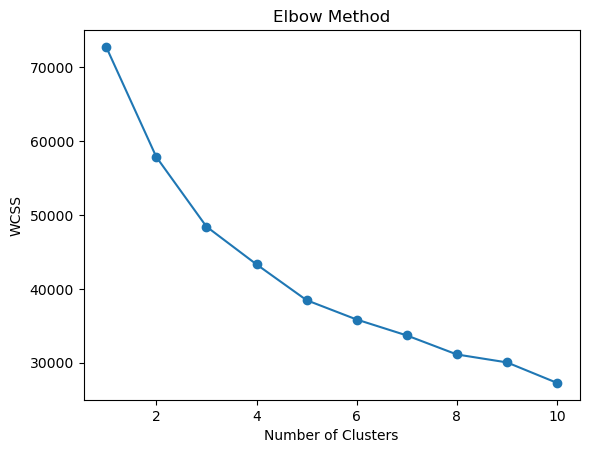

In [55]:
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df2)
    
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [56]:
km=KMeans(n_clusters=4)
km_fitted=km.fit(df2)
km_model=km_fitted.transform(df2)

In [57]:
pd.DataFrame(km_fitted.cluster_centers_)

,0,1,2,3,4,5,6,7
0,4.288818,0.770315,3.753075,4.236667,2.094825,2.823546,1.801532,1.690107
1,2.528125,0.745078,2.490648,3.627531,4.085547,3.947602,3.060070,1.809266
2,1.961090,1.592562,2.004759,1.759792,2.097238,1.742255,2.103677,1.950316
3,3.002667,0.877483,2.452008,3.166803,3.372747,3.065335,3.575425,4.657542


In [63]:
# Cluster 0: Food & café lovers
# Cluster 1: Tourists (beaches + resorts)
# Cluster 2: Cultural visitors (museums + parks)
# Cluster 3: Urban shoppers (malls + restaurants)

In [66]:
df3.groupby("clusters").mean()[["resort", "beaches", "parks"]]

,resort,beaches,parks
clusters,,,
0,1.690025,1.801405,2.096298
1,1.809484,3.061251,4.084832
2,1.950316,2.103677,2.097238
3,4.657542,3.575425,3.372747


In [67]:
a=df3.groupby("clusters").mean()[["resort", "beaches", "parks"]]
b=a.T
b.reset_index(inplace=True)
b.columns=["Variable","cluster0", "cluster1","cluster2", "cluster3"]
b

,Variable,cluster0,cluster1,cluster2,cluster3
0,resort,1.690025,1.809484,1.950316,4.657542
1,beaches,1.801405,3.061251,2.103677,3.575425
2,parks,2.096298,4.084832,2.097238,3.372747


In [68]:
overall=df3.describe().T['mean'].reset_index()
overall.columns=["Variable", "mean"]
overall

,Variable,mean
0,restaurant,3.126542
1,cafes,0.965275
2,pubs_bar,2.832695
3,malls,3.351476
4,parks,2.797103
5,museums,2.893423
6,beaches,2.489059
7,resort,2.320048
8,clusters,1.225889


In [69]:
gh=pd.merge(overall, b, on="Variable", how="inner")
gh

,Variable,mean,cluster0,cluster1,cluster2,cluster3
0,parks,2.797103,2.096298,4.084832,2.097238,3.372747
1,beaches,2.489059,1.801405,3.061251,2.103677,3.575425
2,resort,2.320048,1.690025,1.809484,1.950316,4.657542


In [70]:
df3["clusters"].value_counts()

clusters
0    1972
1    1279
2    1202
3    1001
Name: count, dtype: int64

In [71]:
cluster_profile = df3.groupby('clusters').mean()
cluster_profile

,restaurant,cafes,pubs_bar,malls,parks,museums,beaches,resort
clusters,,,,,,,,
0,4.288560,0.770188,3.753088,4.236141,2.096298,2.823093,1.801405,1.690025
1,2.527146,0.745254,2.489640,3.627866,4.084832,3.949179,3.061251,1.809484
2,1.961090,1.592562,2.004759,1.759792,2.097238,1.742255,2.103677,1.950316
3,3.002667,0.877483,2.452008,3.166803,3.372747,3.065335,3.575425,4.657542


In [72]:
profile = df3.groupby('clusters').mean()
profile.loc['overall_mean'] = df3.mean()

In [73]:
cluster_profile = df3.groupby('clusters').mean().T
cluster_profile['difference'] = abs(cluster_profile[0] - cluster_profile[1])
cluster_profile.sort_values('difference', ascending=False)

clusters,0,1,2,3,difference
parks,2.096298,4.084832,2.097238,3.372747,1.988534
restaurant,4.288560,2.527146,1.961090,3.002667,1.761414
pubs_bar,3.753088,2.489640,2.004759,2.452008,1.263448
beaches,1.801405,3.061251,2.103677,3.575425,1.259846
museums,2.823093,3.949179,1.742255,3.065335,1.126086
malls,4.236141,3.627866,1.759792,3.166803,0.608275
resort,1.690025,1.809484,1.950316,4.657542,0.119459
cafes,0.770188,0.745254,1.592562,0.877483,0.024934


In [75]:
no_clusters=[1,2,3,4,5,6,7,8,9,10]
wcss=[]
for i in no_clusters:
    km=KMeans(n_clusters=i)
    km_fitted=km.fit(df2)
    inertia=km_fitted.inertia_
    wcss.append(inertia)
    print(f"wcss for {i} cluster is = {inertia}")

wcss for 1 cluster is = 72764.53919699299
wcss for 2 cluster is = 57855.44930774544
wcss for 3 cluster is = 48435.30844075531
wcss for 4 cluster is = 43300.490260052524
wcss for 5 cluster is = 38688.82829048393
wcss for 6 cluster is = 36552.70172125443
wcss for 7 cluster is = 35341.896569438686
wcss for 8 cluster is = 30904.910303740096
wcss for 9 cluster is = 29017.997420709464
wcss for 10 cluster is = 28946.834172332812


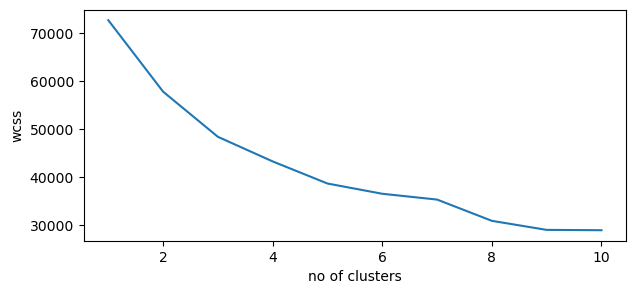

In [76]:

plt.figure(figsize=(7,3))
plt.plot(no_clusters, wcss)
plt.xlabel("no of clusters")
plt.ylabel("wcss")
plt.show()